In [1]:
from pathlib import Path
import os
import pandas as pd
import glob
from datetime import datetime, timedelta
import musclebeachtools as mbt
import criticality_tumbleweed as crt
from d2_tmp_code import *
import numpy as np
import gc
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

/hlabhome/jimmy.zhong/.conda/envs/neural/lib/python3.12/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
INFO     Loaded mrestimator v0.1.8, writing to /tmp/mre_jimmy.zhong/
INFO     Numba not available, skipping parallelization
INFO     No display found. Using non-interactive Agg backend for plotting. Check your $DISPLAY environment variable.


#### Mouse participants summary

RCC00036, 40, 42, 43, 52 are hunters
<br>
RCC00041 (3 successful trials), 45, 53 (1 succesful trial) doesn't hunt.

In [ ]:
roach_hunters = ["RCC00036", "RCC00040", "RCC00042", "RCC00043", "RCC00052"]
non_hunters   = ["RCC00041", "RCC00045", "RCC00053"]
animals = roach_hunters + non_hunters
sorting_thsd_dict = {
    "RCC00036" : 5, "RCC00045" : 5,  "RCC00040" : 5, "RCC00042" : 5, "RCC00041" : 5,
    "RCC00043" : 4.5, "RCC00052": 5, "RCC00053" : 4.5,
}

bin_size_ms = 40
d2_order = 8

# let's start with 1 animal for demo
animal = "RCC00052"

# load in necessary files
preyCaptureRecord = pd.read_csv(f"prey-capture-record/{animal}_PC_record.csv")
preyCaptureRecord["animal"] = animal
preyCaptureRecord["group"] = preyCaptureRecord["animal"].apply(lambda x: "hunter" if x in roach_hunters else "non_hunter")
preyCaptureRecord["total_trial"] = ( preyCaptureRecord["trial"] + (preyCaptureRecord["day"] - 1) * 6 ).clip(lower=0)
sorted_data_format = "neurons_group0.npy"
sorted_loc = f"/media/HlabShare/Clustering_Data/{animal}/block_4hr"
sorted_files = glob.glob(f"{sorted_loc}/*thsd_{sorting_thsd_dict[animal]}/*/probe1/co/*{sorted_data_format}")
print(f"I got {len(sorted_files)} sorted neuron objects for animal: {animal}")

I got 94 sorted neuron objects for animal: RCC00052


#### Calculating the wall time of when the prey capture starts

This "align to wall clock" method is accurate to the seconds.


If we want more precision, we can get 1/16 second precision on the videos (the video is 16Hz) => but it will take me a while to write out the code.
<br>
The quickest Jimmy can do this is by Wednesday.


However, this start time was scored by a human (mostly Jimmy) dragging a bar on a video viewer.
<br>
I don't think having that 1/16 second precision will help us too much.

In [3]:
def to_timedelta(t_str):
    return pd.to_timedelta(t_str)

def compute_wall_time(row):
    filename = row["Video_File"]
    datetime_str = filename.split('-')[1]  # '20250522T103737'
    base_dt = datetime.strptime(datetime_str, "%Y%m%dT%H%M%S")
    delta = pd.to_timedelta(row["start_hunt"])
    return base_dt + delta

preyCaptureRecord["start_wall_time"] = preyCaptureRecord.apply(compute_wall_time, axis=1)
preyCaptureRecord["capture_time_sec"] = pd.to_timedelta(preyCaptureRecord["capture_time"]).dt.total_seconds()

#### Aligning prey capture time to the sorted neuron objects

In [4]:
# --- Step 1: Parse start/end time of each sorted neuron object file ---
def get_time_range(sorted_filename, sorted_data_format): # H_2025-05-19_23-28-10_2025-05-20_03-23-10_neurons_group0.npy'
    time_stamp = Path(sorted_filename).name.replace(sorted_data_format, "")
    _, start_date, start_time, end_date, end_time, _ = time_stamp.split("_")
    s_datetime = datetime.strptime(f"{start_date}-{start_time}", "%Y-%m-%d-%H-%M-%S")
    e_datetime = datetime.strptime(f"{end_date}-{end_time}", "%Y-%m-%d-%H-%M-%S")
    return s_datetime, e_datetime

# --- Step 2: Load and index all sorted neuron object file ---
def build_sorted_file_index(sorted_file_list, sorted_data_format):
    index = []
    for path in sorted_file_list:
        s_time, e_time = get_time_range(path, sorted_data_format)
        index.append({
            "filepath": path,
            "start": s_time,
            "end": e_time
        })
    return pd.DataFrame(index)

# --- Step 3: Match each preyCaptureRecord row to the sorted file ---
def find_matching_sorted_file(timestamp, sorted_index_df):
    match = sorted_index_df[
        (sorted_index_df["start"] <= timestamp) & (timestamp < sorted_index_df["end"])
    ]
    if len(match) == 0:
        return pd.Series([None, None])
    row = match.iloc[0]
    file = row["filepath"]
    short_file = f"hour {Path(file).parent.parent.parent.name}=>{Path(file).name}"
    offset = (timestamp - row["start"]).total_seconds()
    return pd.Series([file, short_file, offset])

# --- Apply all the functions above!!! ---
sorted_index_df = build_sorted_file_index(sorted_files, sorted_data_format)
sorted_index_df = sorted_index_df.sort_values("start").reset_index(drop=True)
# print(sorted_index_df)

# Hunt time (the end of D2 calculation)
preyCaptureRecord[["hunt_sorted_file", "end_info", "hunt_offset_sec"]] = preyCaptureRecord["start_wall_time"].apply(
    lambda t: find_matching_sorted_file(t, sorted_index_df)
)

# Pre-hunt time (the start of D2 calculation)
pre_hunt_buffer = 900 # seconds
preyCaptureRecord["pre_hunt_wall_time"] = preyCaptureRecord["start_wall_time"] - timedelta(seconds=pre_hunt_buffer)
preyCaptureRecord[["start_sorted_file", "start_info", "start_offset_sec"]] = preyCaptureRecord["pre_hunt_wall_time"].apply(
    lambda t: find_matching_sorted_file(t, sorted_index_df)
)

#### Manually fixing some bad recording data that was missing

Also check that everything looks correct

In [5]:
start_at_next_file = [ # the field "start_sorted_file" will take the value of hunt_sorted_file
    ("start_sorted_file", "hunt_sorted_file"),
    ("start_offset_sec", 0.0)
]
end_by_previous_file = [ # the field "hunt_sorted_file" will take the value of start_sorted_file
    ("hunt_sorted_file", "start_sorted_file"),
    ("hunt_offset_sec", -1)
]

# ----- Modify this!!! -----
conditions_and_fixes = {
    "RCC00036_0:00:53": start_at_next_file,
    "RCC00040_0:54:58": end_by_previous_file,
    "RCC00041_0:01:13": start_at_next_file, "RCC00041_0:04:15": start_at_next_file, "RCC00041_0:47:08": end_by_previous_file, "RCC00041_0:54:55": end_by_previous_file, "RCC00041_0:55:50": end_by_previous_file,
    "RCC00042_0:51:49": end_by_previous_file, "RCC00042_0:08:44": start_at_next_file,
    "RCC00043_0:46:42": end_by_previous_file, # 5th trial, idx 4
    "RCC00045_0:06:44": start_at_next_file, # 0th trial,
    "RCC00052_0:50:21": end_by_previous_file, "RCC00052_0:06:52": start_at_next_file, "RCC00052_0:07:11": start_at_next_file, "RCC00052_0:10:24": start_at_next_file,
}

# because some recording during hunt is noisy, in case where I have sorting data for part of the d2 calculation block, I will just grab whetever data's that's available to me
def apply_manual_fixes(df, conditions_and_fixes): 
    for key, fix_list in conditions_and_fixes.items():
        animal, start_hunt = key.split("_")
        condition = ( (df["animal"] == animal) & (df["start_hunt"] == start_hunt) )
        for column_name, val in fix_list:
            if val in ["start_sorted_file", "hunt_sorted_file"]:
                val = (df.loc[condition, val])
            df.loc[condition, column_name] = val
    return df

preyCaptureRecord = apply_manual_fixes(preyCaptureRecord, conditions_and_fixes)
preyCaptureRecord[["end_info", "hunt_offset_sec", "start_hunt", "start_info", "start_offset_sec"]]

,end_info,hunt_offset_sec,start_hunt,start_info,start_offset_sec
0,hour 24_28=>H_2025-07-28_16-00-09_2025-07-28_1...,3784.0,0:56:52,hour 24_28=>H_2025-07-28_16-00-09_2025-07-28_1...,2884.0
1,hour 12_16=>H_2025-07-30_05-54-54_2025-07-30_0...,11909.0,0:12:29,hour 12_16=>H_2025-07-30_05-54-54_2025-07-30_0...,11009.0
2,hour 12_16=>H_2025-07-30_05-54-54_2025-07-30_0...,12783.0,0:27:03,hour 12_16=>H_2025-07-30_05-54-54_2025-07-30_0...,11883.0
3,None,-1.0,0:50:21,hour 12_16=>H_2025-07-30_05-54-54_2025-07-30_0...,13281.0
4,hour 16_20=>H_2025-07-30_09-54-55_2025-07-30_1...,772.0,0:06:52,None,0.0
5,hour 16_20=>H_2025-07-30_09-54-55_2025-07-30_1...,2661.0,0:38:21,hour 16_20=>H_2025-07-30_09-54-55_2025-07-30_1...,1761.0
6,hour 16_20=>H_2025-07-30_09-54-55_2025-07-30_1...,3571.0,0:53:31,hour 16_20=>H_2025-07-30_09-54-55_2025-07-30_1...,2671.0
7,hour 36_40=>H_2025-07-31_05-54-56_2025-07-31_0...,11702.0,0:08:44,hour 36_40=>H_2025-07-31_05-54-56_2025-07-31_0...,10802.0
8,hour 36_40=>H_2025-07-31_05-54-56_2025-07-31_0...,13458.0,0:38:00,hour 36_40=>H_2025-07-31_05-54-56_2025-07-31_0...,12558.0
9,hour 40_44=>H_2025-07-31_09-54-56_2025-07-31_1...,810.0,0:07:11,None,0.0


#### Load in data from the sorted neuron objects and get the binned neuron counts

In [6]:
def get_binned_cross_spikes(sorted_file, start_time, end_time, bin_size_ms, # milliseconds
                            neuron_quality_thsd = 2, verbose=1):
    """
    Computes binned spike counts in a time window.
    2 get_binned_cross_spikes() functions may be used to handle to edge case where the time period spans across 2 sorting blocks.
    
    Parameters:
    -----------
    sorted_file : neurons_group0_file (sorted neurons)
    start_time : when to start the binning (in seconds)
    end_time : when to end, -1 means the end of the file

    Returns:
    --------
    total_hist :  Binned spike counts (sum across neurons).
    """ 
    all_neurons = np.load(sorted_file, allow_pickle=True)
    neurons = [n for n in all_neurons if n.quality <= neuron_quality_thsd]
    s_dur = neurons[0].end_time - neurons[0].start_time # sorting duration

    if end_time == -1:
        end_time = s_dur
    if end_time > s_dur:
        print(f"Sorting actually ends at {s_dur} seconds. Modifying end_time")
        end_time = s_dur
    if start_time > end_time:
        raise ValueError("start_time greater than end_time")

    num_bins = int((end_time - start_time) / (bin_size_ms / 1000))
    total_hist = np.zeros(num_bins)
    
    for i, n in enumerate(neurons):
        spike_times = np.asarray(n.spike_time_sec)
        if spike_times.size == 0:
            continue  # skip empty neurons
        spikes = spike_times[(spike_times >= start_time) & (spike_times < end_time)]
        hist, _ = np.histogram(spikes, bins=num_bins, range=(start_time, end_time)) # bin spikes
        total_hist += hist
        if verbose >= 2:
            print(f"Neuron {i} (clust_idx={n.clust_idx}): {len(spikes)} spikes")

    if verbose:
        print(f"Total spikes across all neurons: {int(total_hist.sum())}")
        print(f"Binned into {num_bins} bins of {bin_size_ms} ms")

    return total_hist

def get_binned_spikes_each_trial(row, bin_size_ms = 20):
    start_file = row["start_sorted_file"]
    end_file = row["hunt_sorted_file"]
    start_sec = row["start_offset_sec"]
    end_sec = row["hunt_offset_sec"]

    if pd.isnull(start_file) or pd.isnull(end_file):
        print(f"Jimmy didn't get both start and end file for animal: {row['animal']}, {row['start_wall_time']} at row {row.name}, skipping!!!")
        return None

    if start_file == end_file:
        total_spikes = get_binned_cross_spikes(start_file, start_sec, end_sec, bin_size_ms, verbose=0) 
    else:
        print("Handling the edge case where D2 calcualtion period spans two sorted neuron files")
        hist1 = get_binned_cross_spikes(start_file, start_sec, -1, bin_size_ms, verbose=0)
        hist2 = get_binned_cross_spikes(end_file, 0, end_sec, bin_size_ms, verbose=0)
        mean_hist1 = np.mean(hist1)
        if mean_hist1 > 0:
            hist2_normalized = hist2 * (mean_hist1 / np.mean(hist2))
        else:
            raise ValueError("YOOOOO, hist1 is all zeros??? check it!")
        total_spikes = np.concatenate([hist1, hist2])
    return total_spikes

preyCaptureRecord["binned_spikes"] = preyCaptureRecord.apply(
    lambda row: get_binned_spikes_each_trial(row, bin_size_ms=20), axis=1
)
gc.collect() # clear out unused memory so Kiran doesn't yell at me

187

#### Calculate D2 and look at the result df

In [7]:
import statsmodels.api as sm

def sm_d2(sig, order):
    coefs, _ = sm.regression.yule_walker(sig, order=order,method="mle")
    return (1-np.sum(coefs))/np.sqrt(order)

def safe_d2_calc(arr, remove_zero = False, d2_order = 5):
    '''
    selection of the d2 order and the bin size is based on this from Sam Sooter's paper:
    "Cortex deviates from criticality during action and deep sleep: a temporal renormalization group approach"
    The primary results here (Fig 2) were robust over a range of model orders (5 to 20) and time bin choices (10 to 160 ms) (Supp Fig S1).
    '''
    if arr is None or isinstance(arr, float) and np.isnan(arr):
        return None
    if remove_zero:
        arr = arr[arr > 0]
    z = zscore(arr)
    d2v1 = sm_d2(z, d2_order)
    return d2v1

preyCaptureRecord["d2_unitless"] = preyCaptureRecord["binned_spikes"].apply(
    lambda x: safe_d2_calc(x, d2_order = 10)
)
preyCaptureRecord["d2_unitless_remove0bin"] = preyCaptureRecord["binned_spikes"].apply(
    lambda x: safe_d2_calc(x, d2_order = 10, remove_zero = True)
)

# check to see these columns
front_cols = ["animal", "group", "day", "trial", "capture_time_sec", "d2_unitless", "d2_unitless_remove0bin"]
other_cols = [col for col in preyCaptureRecord.columns if col not in front_cols]
preyCaptureRecord = preyCaptureRecord[front_cols + other_cols]
preyCaptureRecord[[col for col in preyCaptureRecord.columns if col not in ["binned_spikes", "start_info", "end_info"]]]

,animal,group,day,trial,capture_time_sec,d2_unitless,d2_unitless_remove0bin,start_hunt,end_hunt,capture_time,...,roach_weight,date,Video_File,total_trial,start_wall_time,hunt_sorted_file,hunt_offset_sec,pre_hunt_wall_time,start_sorted_file,start_offset_sec
0,RCC00052,hunter,0,1,1730.0,0.141262,0.142432,0:56:52,1:25:42,0:28:50,...,0.151,7/28/25,RCC00052_bucket_e3v810a-20250728T160621-170621...,0,2025-07-28 17:03:13,/media/HlabShare/Clustering_Data/RCC00052/bloc...,3784.0,2025-07-28 16:48:13,/media/HlabShare/Clustering_Data/RCC00052/bloc...,2884.0
1,RCC00052,hunter,1,1,114.0,0.122400,0.140538,0:12:29,0:14:23,0:01:54,...,0.138,7/22/25,RCC00052_bucket_e3v810a-20250730T090054-100055...,1,2025-07-30 09:13:23,/media/HlabShare/Clustering_Data/RCC00052/bloc...,11909.0,2025-07-30 08:58:23,/media/HlabShare/Clustering_Data/RCC00052/bloc...,11009.0
2,RCC00052,hunter,1,2,97.0,0.051856,0.115530,0:27:03,0:28:40,0:01:37,...,0.090,7/22/25,RCC00052_bucket_e3v810a-20250730T090054-100055...,2,2025-07-30 09:27:57,/media/HlabShare/Clustering_Data/RCC00052/bloc...,12783.0,2025-07-30 09:12:57,/media/HlabShare/Clustering_Data/RCC00052/bloc...,11883.0
3,RCC00052,hunter,1,3,126.0,0.086694,0.114625,0:50:21,0:52:27,0:02:06,...,0.101,7/22/25,RCC00052_bucket_e3v810a-20250730T090054-100055...,3,2025-07-30 09:51:15,/media/HlabShare/Clustering_Data/RCC00052/bloc...,-1.0,2025-07-30 09:36:15,/media/HlabShare/Clustering_Data/RCC00052/bloc...,13281.0
4,RCC00052,hunter,1,4,76.0,0.084170,0.108502,0:06:52,0:08:08,0:01:16,...,0.168,7/22/25,RCC00052_bucket_e3v810a-20250730T100055-110056...,4,2025-07-30 10:07:47,/media/HlabShare/Clustering_Data/RCC00052/bloc...,772.0,2025-07-30 09:52:47,/media/HlabShare/Clustering_Data/RCC00052/bloc...,0.0
5,RCC00052,hunter,1,5,204.0,0.092734,0.116106,0:38:21,0:41:45,0:03:24,...,0.098,7/22/25,RCC00052_bucket_e3v810a-20250730T100055-110056...,5,2025-07-30 10:39:16,/media/HlabShare/Clustering_Data/RCC00052/bloc...,2661.0,2025-07-30 10:24:16,/media/HlabShare/Clustering_Data/RCC00052/bloc...,1761.0
6,RCC00052,hunter,1,6,94.0,0.077353,0.101021,0:53:31,0:55:05,0:01:34,...,0.162,7/22/25,RCC00052_bucket_e3v810a-20250730T100055-110056...,6,2025-07-30 10:54:26,/media/HlabShare/Clustering_Data/RCC00052/bloc...,3571.0,2025-07-30 10:39:26,/media/HlabShare/Clustering_Data/RCC00052/bloc...,2671.0
7,RCC00052,hunter,2,1,41.0,0.106198,0.124410,0:08:44,0:09:25,0:00:41,...,0.152,7/23/25,RCC00052_bucket_e3v810a-20250731T090114-100115...,7,2025-07-31 09:09:58,/media/HlabShare/Clustering_Data/RCC00052/bloc...,11702.0,2025-07-31 08:54:58,/media/HlabShare/Clustering_Data/RCC00052/bloc...,10802.0
8,RCC00052,hunter,2,2,72.0,0.079132,0.103021,0:38:00,0:39:12,0:01:12,...,0.188,7/23/25,RCC00052_bucket_e3v810a-20250731T090114-100115...,8,2025-07-31 09:39:14,/media/HlabShare/Clustering_Data/RCC00052/bloc...,13458.0,2025-07-31 09:24:14,/media/HlabShare/Clustering_Data/RCC00052/bloc...,12558.0
9,RCC00052,hunter,2,3,63.0,0.066804,0.079446,0:07:11,0:08:14,0:01:03,...,0.189,7/23/25,RCC00052_bucket_e3v810a-20250731T100115-110115...,9,2025-07-31 10:08:26,/media/HlabShare/Clustering_Data/RCC00052/bloc...,810.0,2025-07-31 09:53:26,/media/HlabShare/Clustering_Data/RCC00052/bloc...,0.0


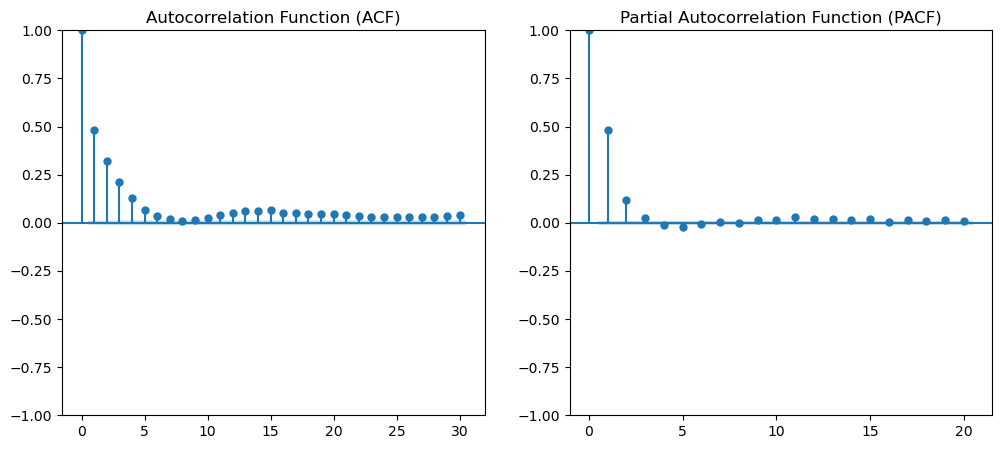

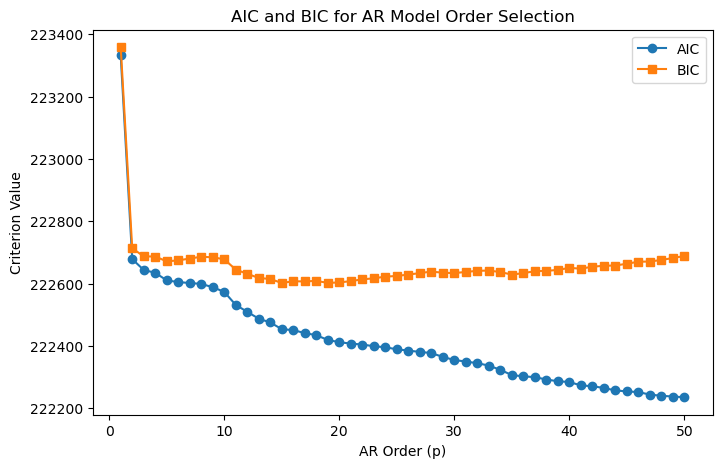

Optimal AR order based on AIC: 50
Optimal AR order based on BIC: 15


In [8]:
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

pop_data = preyCaptureRecord["binned_spikes"][0]

# Plot ACF & PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ACF plot
plot_acf(pop_data, lags=30, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF)")

# PACF plot
plot_pacf(pop_data, lags=20, ax=axes[1], method="ywm")
axes[1].set_title("Partial Autocorrelation Function (PACF)")

plt.show()

# Determine optimal AR order
max_lag = 50  # Define max order to check
aic_values = []
bic_values = []
lags = list(range(1, max_lag+1))

for p in lags:
    model = AutoReg(pop_data, lags=p).fit()
    aic_values.append(model.aic)
    bic_values.append(model.bic)

# Plot AIC and BIC values
plt.figure(figsize=(8, 5))
plt.plot(lags, aic_values, label='AIC', marker='o')
plt.plot(lags, bic_values, label='BIC', marker='s')
plt.xlabel('AR Order (p)')
plt.ylabel('Criterion Value')
plt.title('AIC and BIC for AR Model Order Selection')
plt.legend()
plt.show()

# Find the optimal order
optimal_p_aic = lags[np.argmin(aic_values)]
optimal_p_bic = lags[np.argmin(bic_values)]

print(f"Optimal AR order based on AIC: {optimal_p_aic}")
print(f"Optimal AR order based on BIC: {optimal_p_bic}")

#### Piecing all functions together and run it on all mice

In [9]:
bin_size_ms = 50
d2_order = 10

def get_d2_df(animal, sorting_thsd, bin_size_ms, pre_hunt_buffer = 600):
    sorted_data_format = "neurons_group0.npy"
    sorted_files = glob.glob(f"/media/HlabShare/Clustering_Data/{animal}/block_4hr/*thsd_{sorting_thsd}/*/probe1/co/*{sorted_data_format}")
    print(f"I got {len(sorted_files)} sorted neuron objects for animal: {animal}")
    sorted_index_df = build_sorted_file_index(sorted_files, sorted_data_format)
    sorted_index_df = sorted_index_df.sort_values("start").reset_index(drop=True)
    
    preyCaptureRecord = pd.read_csv(f"{animal}_PC_record.csv")
    preyCaptureRecord["animal"] = animal
    preyCaptureRecord["group"] = preyCaptureRecord["animal"].apply(lambda x: "hunter" if x in roach_hunters else "non_hunter")
    preyCaptureRecord["total_trial"] = ( preyCaptureRecord["trial"] + (preyCaptureRecord["day"] - 1) * 6 ).clip(lower=0)
    preyCaptureRecord["start_wall_time"] = preyCaptureRecord.apply(compute_wall_time, axis=1)
    preyCaptureRecord["capture_time_sec"] = pd.to_timedelta(preyCaptureRecord["capture_time"]).dt.total_seconds()

    # Hunt time (the end of D2 calculation)
    preyCaptureRecord[["hunt_sorted_file", "end_info", "hunt_offset_sec"]] = preyCaptureRecord["start_wall_time"].apply(
        lambda t: find_matching_sorted_file(t, sorted_index_df)
    )

    # Pre-hunt time (the start of D2 calculation)
    preyCaptureRecord["pre_hunt_wall_time"] = preyCaptureRecord["start_wall_time"] - timedelta(seconds=pre_hunt_buffer)
    preyCaptureRecord[["start_sorted_file", "start_info", "start_offset_sec"]] = preyCaptureRecord["pre_hunt_wall_time"].apply(
        lambda t: find_matching_sorted_file(t, sorted_index_df)
    )
    
    # apply manual fixes
    preyCaptureRecord = apply_manual_fixes(preyCaptureRecord, conditions_and_fixes)

    # bin spikes
    preyCaptureRecord["binned_spikes"] = preyCaptureRecord.apply(
        lambda row: get_binned_spikes_each_trial(row, bin_size_ms=bin_size_ms), axis=1
    )
    # calculate d2
    preyCaptureRecord["d2_unitless"] = preyCaptureRecord["binned_spikes"].apply(
        lambda x: safe_d2_calc(x, d2_order = 10)
    )
    preyCaptureRecord["d2_unitless_remove0bin"] = preyCaptureRecord["binned_spikes"].apply(
        lambda x: safe_d2_calc(x, d2_order = 10, remove_zero = True)
    )
    # just for visual, wanna see these columns in front
    front_cols = ["animal", "day", "total_trial", "trial", "capture_time_sec", "d2_unitless", "d2_unitless_remove0bin"]
    other_cols = [col for col in preyCaptureRecord.columns if col not in front_cols]
    preyCaptureRecord = preyCaptureRecord[front_cols + other_cols]
    return preyCaptureRecord

tmp_df_pointers = []

for animal in animals:
    tmp_df_pointers.append(get_d2_df(animal, sorting_thsd_dict[animal], bin_size_ms = bin_size_ms))
    gc.collect() # memory cleaning

animals_preyCaptureRec = pd.concat(tmp_df_pointers, ignore_index=True)

I got 60 sorted neuron objects for animal: RCC00036
Jimmy didn't get both start and end file for animal: RCC00036, 2025-05-22 11:34:36 at row 6, skipping!!!
I got 98 sorted neuron objects for animal: RCC00040
I got 85 sorted neuron objects for animal: RCC00042
Jimmy didn't get both start and end file for animal: RCC00042, 2025-05-31 08:52:11 at row 7, skipping!!!
I got 79 sorted neuron objects for animal: RCC00043
Jimmy didn't get both start and end file for animal: RCC00043, 2025-06-06 10:33:27 at row 5, skipping!!!
I got 94 sorted neuron objects for animal: RCC00052
I got 90 sorted neuron objects for animal: RCC00041
Jimmy didn't get both start and end file for animal: RCC00041, 2025-05-24 11:33:10 at row 16, skipping!!!
Jimmy didn't get both start and end file for animal: RCC00041, 2025-05-24 12:04:15 at row 17, skipping!!!
Jimmy didn't get both start and end file for animal: RCC00041, 2025-05-24 12:34:42 at row 18, skipping!!!
I got 80 sorted neuron objects for animal: RCC00045
Han

#### Boxplot: do different animals tend to have different D2, 15 mintues before hunting?

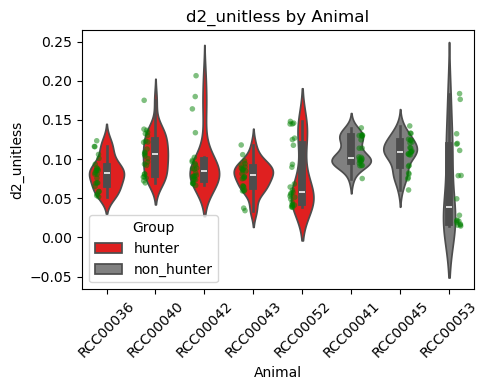

In [10]:
def plot_d2_by_animal(df, y_column):
    plt.figure(figsize=(5, 4))
    sns.violinplot(x="animal", y=y_column, hue="group", data=df, inner="box", palette={"hunter": "red", "non_hunter": "gray"})
    # sns.boxplot( x="animal", y=y_column, hue="group", data=df, palette={"hunter": "red", "non_hunter": "gray"}, dodge=True, fliersize=0)
    sns.stripplot(
        x="animal", y=y_column, hue="group", data=df,
        palette={"hunter": "green", "non_hunter": "green"},
        dodge=True, jitter=True, size=4, alpha=0.5
    )

    # Remove duplicate legend entries
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles[:2], labels[:2], title="Group")

    plt.title(f"{y_column} by Animal")
    plt.xlabel("Animal")
    plt.ylabel(y_column)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# print(animals_preyCaptureRec[animals_preyCaptureRec["animal"] == "RCC00053"])

plot_d2_by_animal(animals_preyCaptureRec, "d2_unitless")

#### What's wrong with the D2 values for RCC00053???

RCC00053 has bad recording: every 1-2 seconds or so, we receive some really high amplitude noise, or lost of data.
<br>
The cable / headstage is not very good. Thus, there are a lot of bins with 0 neurons.

Let me show you a normal (above, RCC00040) binned data and a binned data from RCC00053

animal                                                             RCC00040
start_info                hour 12_16=>H_2025-05-15_08-21-22_2025-05-15_1...
d2_unitless                                                        0.136797
d2_unitless_remove0bin                                             0.136797
Name: 33, dtype: object


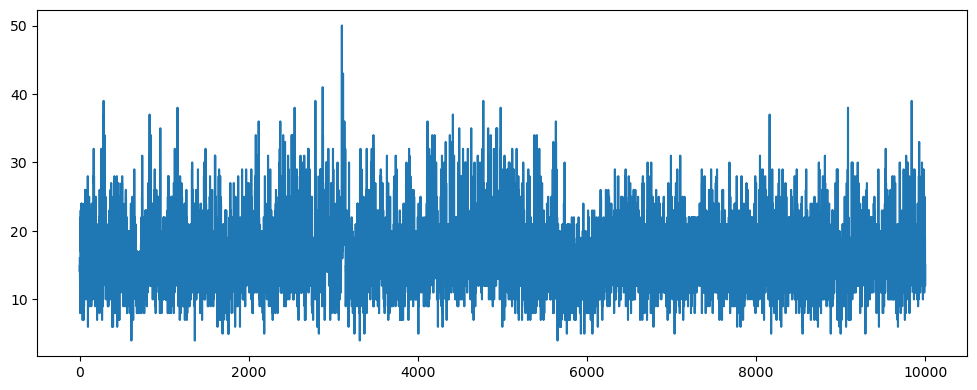

animal                                                             RCC00053
start_info                hour 16_20=>H_2025-07-23_08-13-25_2025-07-23_1...
d2_unitless                                                         0.01903
d2_unitless_remove0bin                                             0.083788
Name: 183, dtype: object


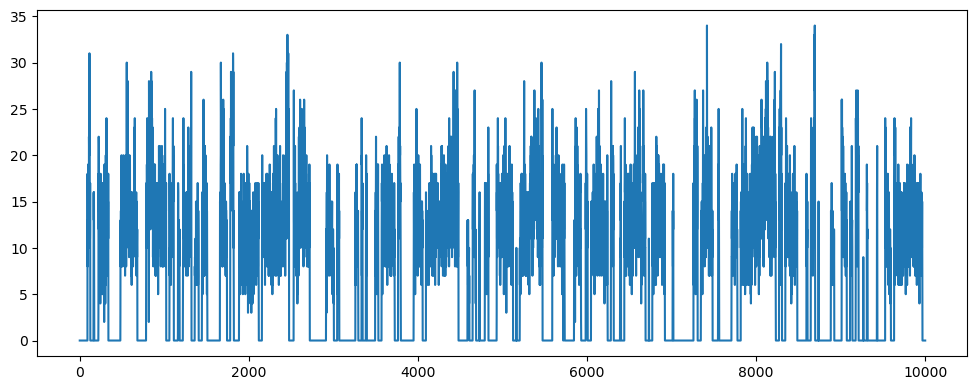

In [11]:
show_col = ["animal", "start_info", "d2_unitless", "d2_unitless_remove0bin"]
# showing RCC00040
idx = 33
print(animals_preyCaptureRec.iloc[idx][show_col])
plt.figure(figsize=(12, 4.5))
plt.plot(animals_preyCaptureRec.iloc[idx]["binned_spikes"][:10000])
plt.show()

# showing RCC00053
idx = -15
print(animals_preyCaptureRec.iloc[idx][show_col])
plt.figure(figsize=(12, 4.5))
plt.plot(animals_preyCaptureRec.iloc[idx]["binned_spikes"][:10000])
plt.show()

#### Making another boxplot that takes out zero-bins for all mouse

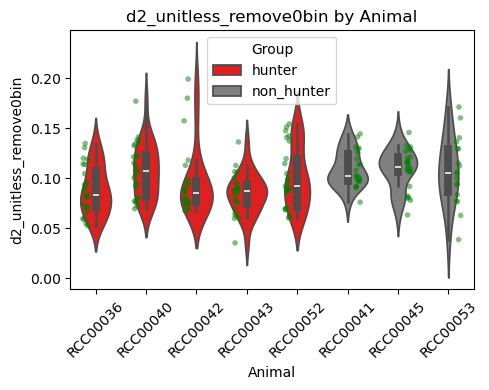

In [12]:
d2_var = "d2_unitless_remove0bin"

plot_d2_by_animal(animals_preyCaptureRec, d2_var)

#### Doing linear mixed effect model to test whether Non-hunter have higher D2 than hunters

Non-hunters have a D2 that is ~0.02 higher on average than hunters.

Group Var: 0.000 => each animals in a group do not differ.

This difference between hunter and non-hunters is significant.

In [13]:
import statsmodels.formula.api as smf
from scipy.stats import norm

df = animals_preyCaptureRec
df_clean = df.dropna(subset=[d2_var])

model = smf.mixedlm(f"{d2_var} ~ group", df_clean, groups=df_clean["animal"])
result = model.fit()

print(result.summary())

coef = result.params["group[T.non_hunter]"]
se = result.bse["group[T.non_hunter]"]
z = coef / se
pval_one_tailed = 1 - norm.cdf(z)

print(f"One-tailed p-value (H1: group effect > 0): {pval_one_tailed:.4f}")

               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: d2_unitless_remove0bin
No. Observations: 187     Method:             REML                  
No. Groups:       8       Scale:              0.0007                
Min. group size:  18      Log-Likelihood:     401.9023              
Max. group size:  25      Converged:          Yes                   
Mean group size:  23.4                                              
---------------------------------------------------------------------
                       Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------------------
Intercept              0.096     0.003  27.803  0.000   0.089   0.102
group[T.non_hunter]    0.013     0.006   2.321  0.020   0.002   0.025
Group Var              0.000     0.001                               

One-tailed p-value (H1: group effect > 0): 0.0101


#### Line Plot: show the trend of d2 over time for each animal

Red is the hunters, Gray is non-hunter

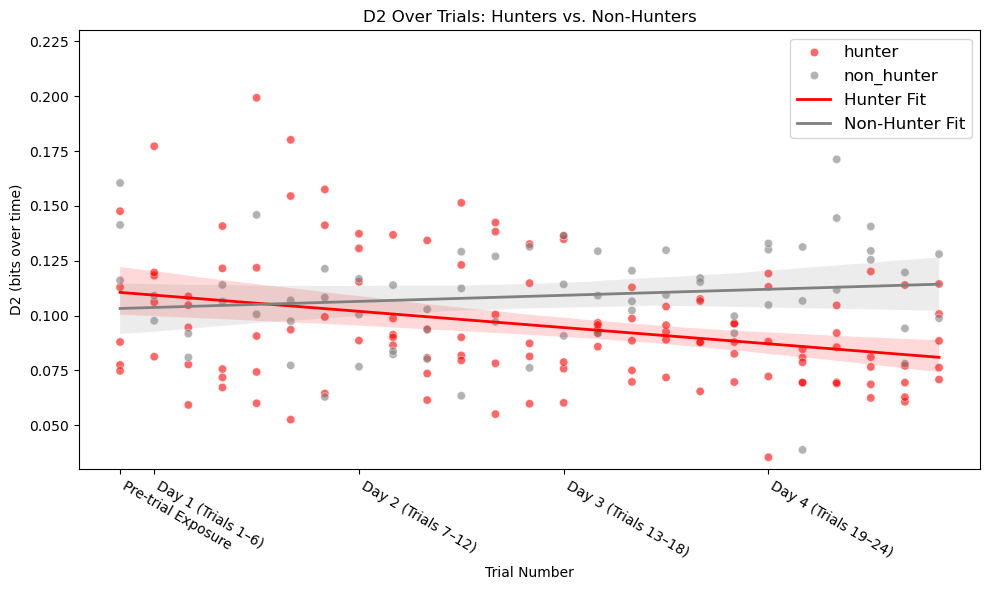

In [14]:
df = animals_preyCaptureRec

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="total_trial", y=d2_var, hue="group",
                palette={"hunter": "red", "non_hunter": "gray"}, alpha=0.6)

# Regression lines
sns.regplot(data=df[df["group"] == "hunter"], x="total_trial", y=d2_var,
            scatter=False, color="red", label="Hunter Fit", line_kws={"linestyle": "solid", "linewidth": 2})
sns.regplot(data=df[df["group"] == "non_hunter"], x="total_trial", y=d2_var,
            scatter=False, color="gray", label="Non-Hunter Fit", line_kws={"linestyle": "solid", "linewidth": 2})

xticks = [0, 1, 7, 13, 19]
xtick_labels = ["Pre-trial Exposure", "Day 1 (Trials 1–6)", "Day 2 (Trials 7–12)",
                "Day 3 (Trials 13–18)", "Day 4 (Trials 19–24)"]
plt.xticks(xticks, xtick_labels, rotation=-30, ha="left")

plt.title("D2 Over Trials: Hunters vs. Non-Hunters")
plt.ylim((0.03, 0.23))
plt.xlabel("Trial Number")
plt.ylabel("D2 (bits over time)")
plt.legend(fontsize = 12, loc='upper right')
plt.tight_layout()
plt.show()

#### Among hunters, do lower-d2 (near criticality) means better performance?

Performance is measure by log(capture time in seconds).

D2 is probably not normally distributed, but I don't want it log it (what does a logged d2 even mean?)

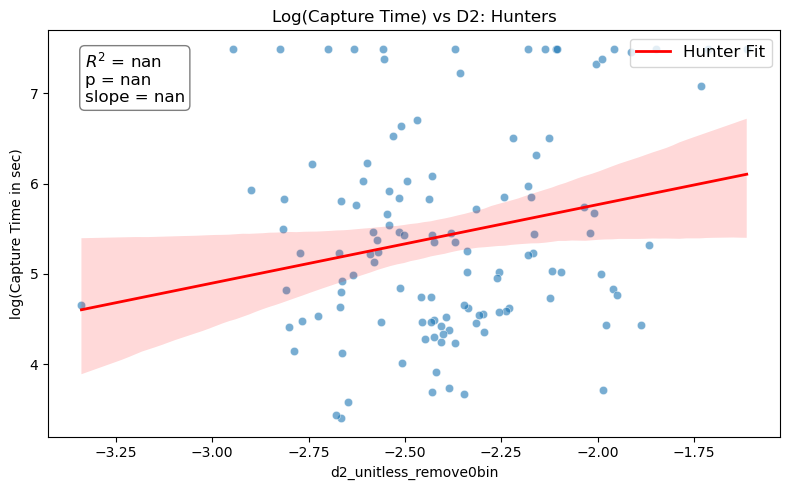

In [15]:
from scipy.stats import linregress

df = animals_preyCaptureRec.copy()
df = df[df["group"] == "hunter"]
df = df[df["capture_time_sec"] <= 1800]

df['log_capture_time'] = np.log(df['capture_time_sec'])
df['log_d2'] = np.log(df[d2_var])

# simple linear regression, don't interpret it statistically
slope, intercept, r_value, p_value, std_err = linregress(df['log_d2'], df['log_capture_time'])

plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='log_d2', y="log_capture_time", alpha=0.6)
sns.regplot(data=df, x='log_d2', y="log_capture_time", scatter=False, color="red",
            line_kws={"linestyle": "solid", "linewidth": 2}, label="Hunter Fit")

# Format regression stats
stats_text = f"$R^2$ = {r_value**2:.3f}\np = {p_value:.3g}\nslope = {slope:.3f}"

# Add text box to plot
plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes,
         verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.5), fontsize=12)

plt.title("Log(Capture Time) vs D2: Hunters")
plt.xlabel(d2_var)
plt.ylabel("log(Capture Time in sec)")
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()

#### Accessing the accelerometer data

In [16]:
def jimmy_plot_data_chlist(data, data_beg, data_end, ch_list=None,
                     sampling_rate=25000, ylim_default = (-300, 300), 
                     file_name_with_path=None,
                     title_string=None):

    fig, ax = plt.subplots(nrows=len(ch_list), ncols=1,
                           figsize=(16, 2 * len(ch_list)))

    ax[0].set_title(title_string)
    for indx, channel in enumerate(ch_list):
        data_ch = data[channel, data_beg:data_end]
        sns.lineplot(
            x=range(len(data_ch)),
            y=data_ch,
            ax=ax[indx],
            color="black",
            linestyle='-',
            markersize=0.5,
            label=f'Ch{channel}',
            zorder=1.0
        )

        # Styling subplots
        ax[indx].legend(fontsize=6, loc='upper right')
        ax[indx].spines['top'].set_visible(False)
        ax[indx].spines['right'].set_visible(False)
        ax[indx].spines['left'].set_visible(False)
        ax[indx].spines['bottom'].set_visible(False)

        # Only show x-label for the last subplot
        if indx == (len(ch_list) - 1):
            ax[indx].set_xlabel(f'Samples [Samples/{sampling_rate} = Seconds]',
                                fontsize=10)
            ax[indx].set_ylabel('Amplitude [\u03bcV]', fontsize=10)
            ax[indx].tick_params(axis='x', which='both',
                                 bottom=True, top=True,
                                 labelbottom=True)

        else:
            ax[indx].set_xticklabels([])
            ax[indx].tick_params(axis='x', which='both',
                                 bottom=False, top=False,
                                 labelbottom=False)
        ax[indx].set_ylim(ylim_default)
    plt.tight_layout()

    if file_name_with_path is None:
        plt.show()
    else:
        plt.savefig(file_name_with_path)

In [17]:
# download_keys = {a:[] for a in animals}

# for f in set(list(animals_preyCaptureRec["hunt_sorted_file"]) + list(animals_preyCaptureRec["start_sorted_file"])):
#     if f:
#         split_f = f.split("/")
#         animal, restart, hour = split_f[4], split_f[6], split_f[7]
#         restart = restart.split("_thsd_")[0]
#         path = glob.glob(f'/media/HlabShare/Accelerometer/{animal}/block_4hr/{restart}/{hour}/co/*_lfp_group0.npy', recursive = True)
#         scp_path = f"jimmy.zhong@marvin.wustl.edu:{path[0]}"
#         download_keys[animal].append(scp_path)

In [18]:
animal = "RCC00036"
path = glob.glob(f'/media/HlabShare/Accelerometer/RCC00036/block_4hr/RCC00036_L1_W2_2025-05-23_16-17-18/16_20/co/*_lfp_group0.npy', recursive = True)
acce_f = path[0]
print(acce_f)

start_time, end_time = get_time_range(acce_f, "lfp_group0.npy")
acce_list = np.load(acce_f)

/media/HlabShare/Accelerometer/RCC00036/block_4hr/RCC00036_L1_W2_2025-05-23_16-17-18/16_20/co/H_2025-05-24_08-17-20_2025-05-24_12-12-20_lfp_group0.npy


(9, 7200007)
[[-1.000e+01 -1.000e+00  2.000e+00 ...  2.200e+01 -2.000e+00 -6.000e+00]
 [ 1.000e+01  9.000e+00  1.600e+01 ... -3.750e+02 -2.000e+02 -1.030e+02]
 [ 2.000e+00  2.400e+01  2.100e+01 ... -1.294e+03 -8.430e+02 -1.480e+02]
 ...
 [ 0.000e+00  0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00  0.000e+00]
 [ 0.000e+00  0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00  0.000e+00]
 [ 0.000e+00  0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00  0.000e+00]] 



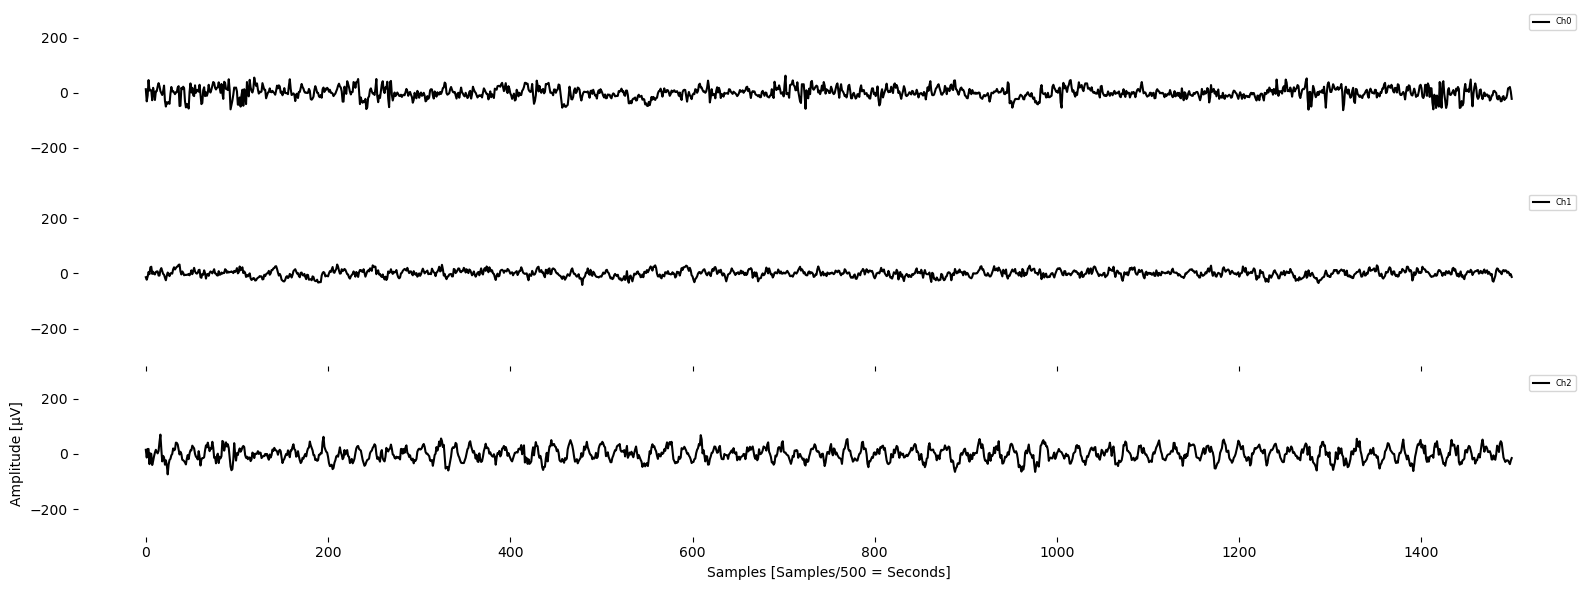

In [19]:
ch_list = list(range(0,9))
print(f'{acce_list.shape}')
print(acce_list,'\n')

which = 1 # use to select between different segments of the recording.
fs = 500 # converted from 25000Hz to 500Hz by the sorter, for every sort

timeinterval = fs*3
ts = 0 + which*(timeinterval)
te = timeinterval + which*(timeinterval)

jimmy_plot_data_chlist(acce_list, data_beg=ts, data_end=te, ch_list=list(range(3)),
                     sampling_rate=fs,
                     file_name_with_path=None)

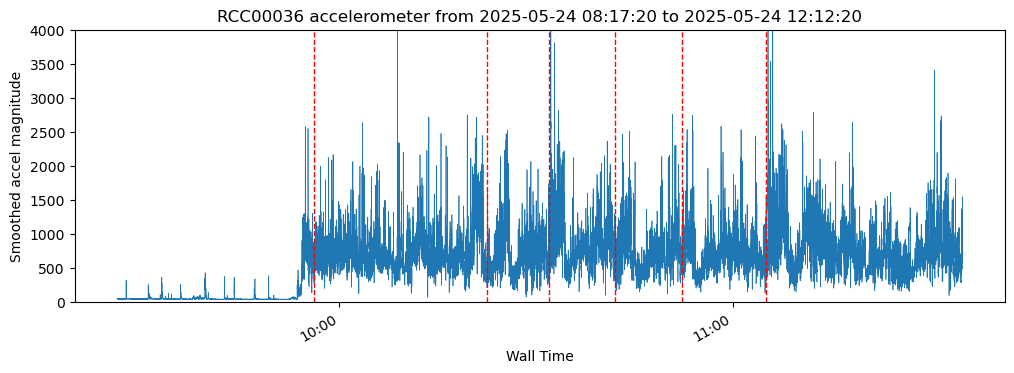

In [20]:
import matplotlib.dates as mdates
# H_2025-07-23_12-13-26_2025-07-23_16-08-26_lfp_group0.npy

### [0,1,2] => linear acceleration, [4,5,6] => angular/gyroscope stuff, acce_list
xyz_accel_magnitude = np.sqrt(np.sum(np.array(acce_list[0:3], dtype='int64')**2, axis=0))

from scipy.ndimage import gaussian_filter1d
fs = 500  # Hz
sigma = 100  # each sample is 2ms

# Smooth
x_smooth = gaussian_filter1d(xyz_accel_magnitude, sigma=sigma)

# Build datetime axis
time_axis = np.array([start_time + timedelta(seconds=i/fs) for i in range(len(x_smooth))])

animal_start_times = animals_preyCaptureRec[animals_preyCaptureRec["animal"] == animal]["start_wall_time"]
prey_capture_times = [x for x in list(animal_start_times) if x.date() == start_time.date()]
window_start = prey_capture_times[0] - timedelta(minutes=30)
window_end   = prey_capture_times[-1] + timedelta(minutes=30)

# mask the data
mask = (time_axis >= window_start) & (time_axis <= window_end)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(time_axis[mask][::10], x_smooth[mask][::10], lw=0.5)
plt.xlabel("Wall Time")
plt.ylabel("Smoothed accel magnitude")
plt.title(f"{animal} accelerometer from {str(start_time)} to {str(end_time)}")
plt.ylim((0, 4000))

for event_time in prey_capture_times:
    plt.axvline(x=event_time, color="red", linestyle='--', linewidth=1)

# Format x-axis to show hours:minutes
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))  # tick every 1 hr
plt.gcf().autofmt_xdate()

plt.show()

#### Doing acceleration check in a row

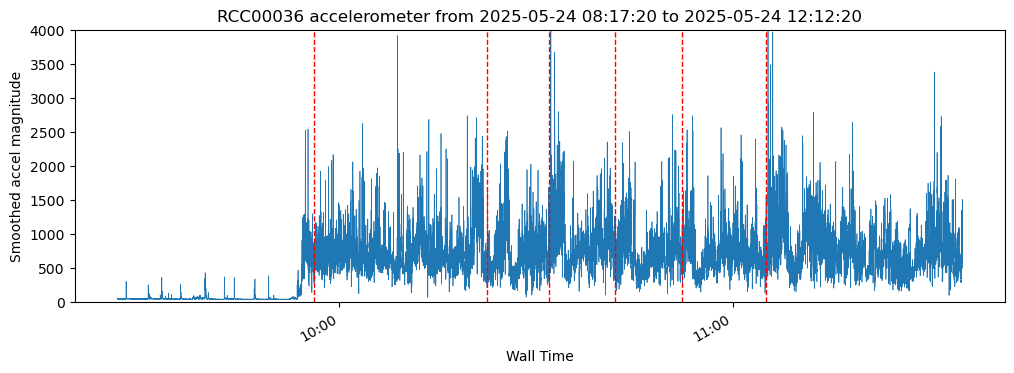

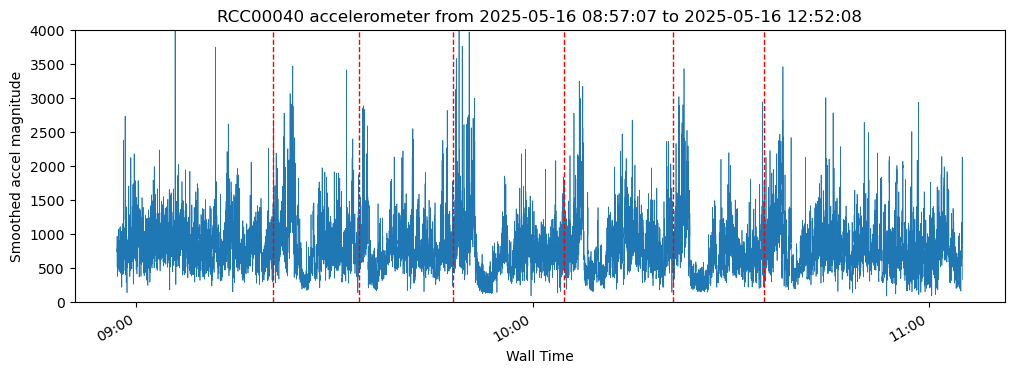

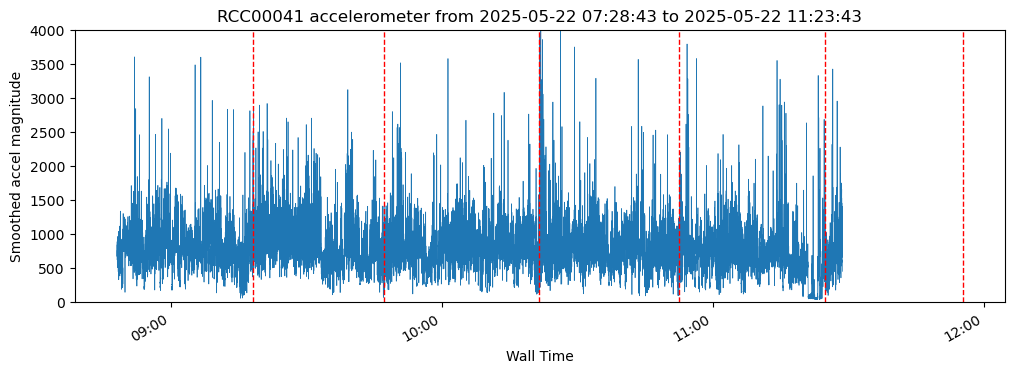

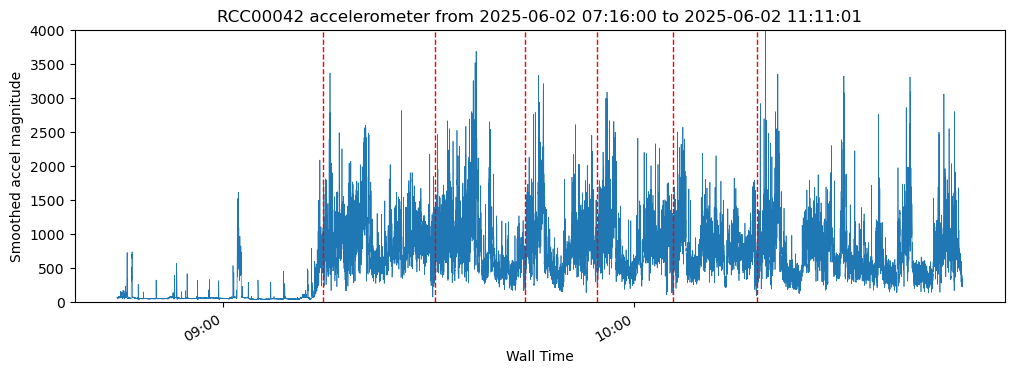

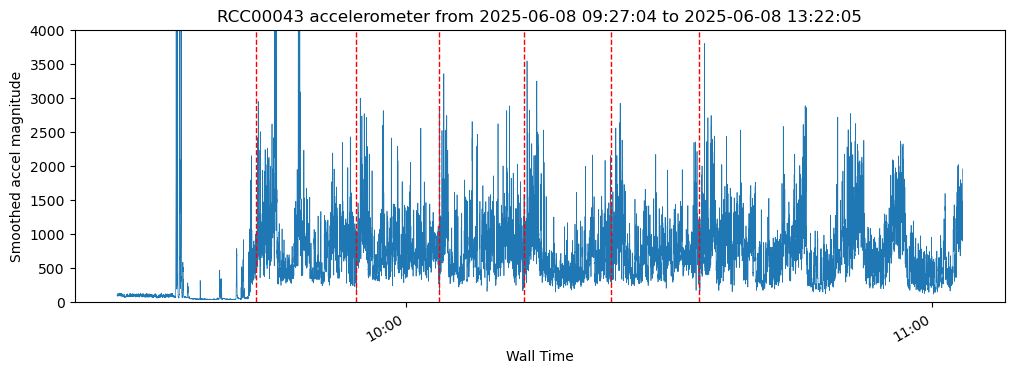

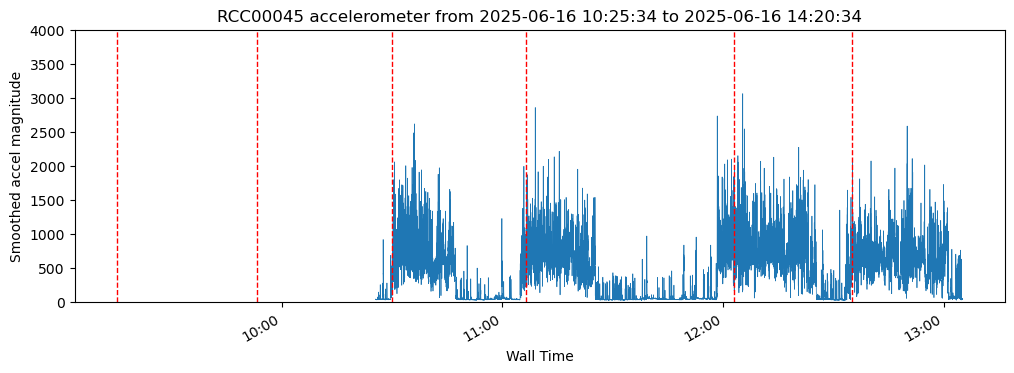

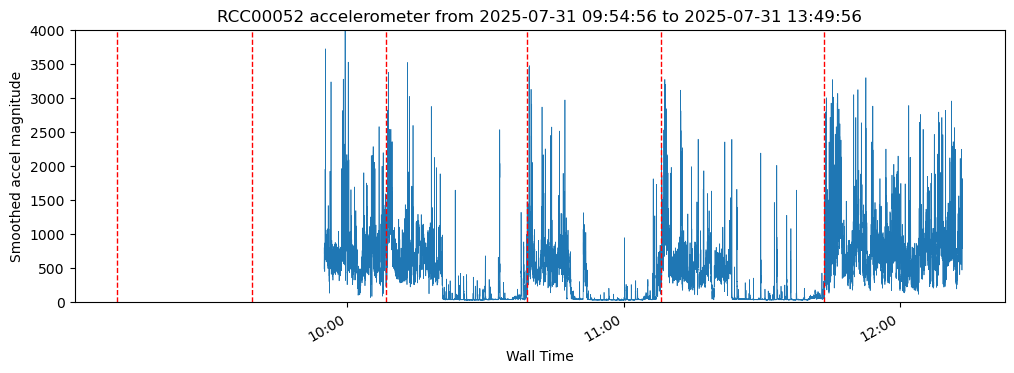

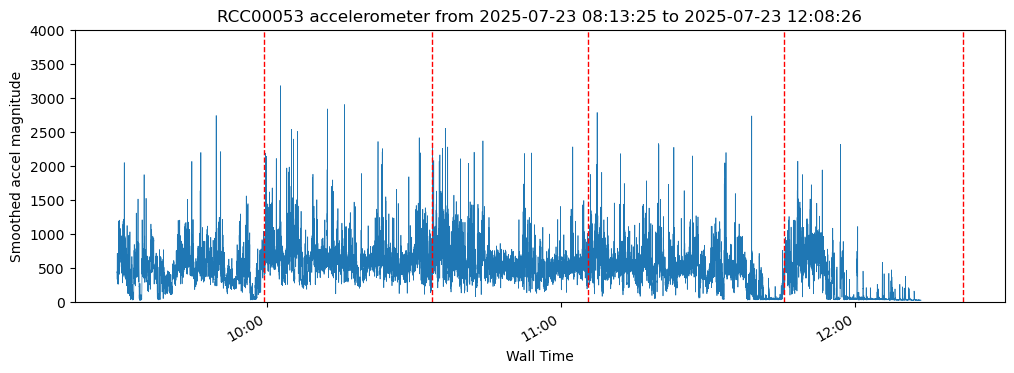

In [21]:
demo_acceleration = {
    "RCC00036": '/media/HlabShare/Accelerometer/RCC00036/block_4hr/RCC00036_L1_W2_2025-05-23_16-17-18/16_20/co/H_2025-05-24_08-17-20_2025-05-24_12-12-20_lfp_group0.npy',
    "RCC00040": '/media/HlabShare/Accelerometer/RCC00040/block_4hr/RCC00040_L5_W2_2025-05-16_08-57-06/0_4//co/H_2025-05-16_08-57-07_2025-05-16_12-52-08_lfp_group0.npy',
    "RCC00041": '/media/HlabShare/Accelerometer/RCC00041/block_4hr/RCC00041_L5_W2_2025-05-19_11-28-39/68_72/co/H_2025-05-22_07-28-43_2025-05-22_11-23-43_lfp_group0.npy',
    "RCC00042": '/media/HlabShare/Accelerometer/RCC00042/block_4hr/RCC00042_L5_W2_2025-05-31_15-15-58/40_44/co/H_2025-06-02_07-16-00_2025-06-02_11-11-01_lfp_group0.npy',
    "RCC00043": '/media/HlabShare/Accelerometer/RCC00043/block_4hr/RCC00043_L5_W2_2025-06-08_09-27-03/0_4/co/H_2025-06-08_09-27-04_2025-06-08_13-22-05_lfp_group0.npy',
    "RCC00045": "/media/HlabShare/Accelerometer/RCC00045/block_4hr/RCC00045_L5_W2_2025-06-13_14-25-30/68_72/co/H_2025-06-16_10-25-34_2025-06-16_14-20-34_lfp_group0.npy",
    "RCC00052": '/media/HlabShare/Accelerometer/RCC00052/block_4hr/RCC00052_L5_W2_2025-07-29_17-54-53/40_44/co/H_2025-07-31_09-54-56_2025-07-31_13-49-56_lfp_group0.npy',
    "RCC00053": "/media/HlabShare/Accelerometer/RCC00053/block_4hr/RCC00053_L5_W2_2025-07-22_16-13-24/16_20/co/H_2025-07-23_08-13-25_2025-07-23_12-08-26_lfp_group0.npy",
}

fs = 500

for animal, acce_f in demo_acceleration.items():
    start_time, end_time = get_time_range(acce_f, "lfp_group0.npy")
    acce_list = np.load(acce_f)
    ### [0,1,2] => linear acceleration, [4,5,6] => angular/gyroscope stuff, acce_list
    xyz_accel_magnitude = np.sqrt(np.sum(np.array(acce_list[0:3], dtype='int64')**2, axis=0))
    x_smooth = gaussian_filter1d(xyz_accel_magnitude, sigma=100)
    time_axis = np.array([start_time + timedelta(seconds=i/fs) for i in range(len(x_smooth))])

    animal_start_times = animals_preyCaptureRec[animals_preyCaptureRec["animal"] == animal]["start_wall_time"]
    prey_capture_times = [x for x in list(animal_start_times) if x.date() == start_time.date()]
    window_start = prey_capture_times[0] - timedelta(minutes=30)
    window_end   = prey_capture_times[-1] + timedelta(minutes=30)
    
    mask = (time_axis >= window_start) & (time_axis <= window_end)
    plt.figure(figsize=(12, 4))
    plt.plot(time_axis[mask][::100], x_smooth[mask][::100], lw=0.5)
    plt.xlabel("Wall Time")
    plt.ylabel("Smoothed accel magnitude")
    plt.title(f"{animal} accelerometer from {str(start_time)} to {str(end_time)}")
    plt.ylim((0, 4000))
    
    for event_time in prey_capture_times:
        plt.axvline(x=event_time, color="red", linestyle='--', linewidth=1)
    
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))  # tick every 1 hr
    plt.gcf().autofmt_xdate()
    
    plt.show()

#### Save the preyCaptureRec with 20ms bins

If future people want to play with the data, <b>20ms</b> should be the smallest unit?
<br>
If you want 100ms bins, just add 5 consecutive 20ms bins.

Also, I saved binnned neural activity <b> 1800 </b> seconds before the start of the hunt (we give each mouse 30 minutes to catch / eat a roach. There are 6 roaches / trials per day). You can pick what you need from that 1800 seconds.

In [22]:
# tmp_df_pointers = []

# for animal in animals:
#     tmp_df_pointers.append(get_d2_df(animal, sorting_thsd_dict[animal], bin_size_ms = 20, pre_hunt_buffer = 1800))
#     gc.collect() # memory cleaning

# saved_preyCaptureRec = pd.concat(tmp_df_pointers, ignore_index=True)
# saved_preyCaptureRec["binned_spikes_str"] = saved_preyCaptureRec["binned_spikes"].apply(
#     lambda x: ",".join(map(lambda y: str(int(y)), x)) if x is not None else ""
# )
# to_csv_PCR = saved_preyCaptureRec.drop(columns=["binned_spikes"])
# to_csv_PCR.to_csv(f"preyCaptureRecord_with_binned_neural_activity.csv", index=False)